<a href="https://colab.research.google.com/github/meryuzlu/Grover-Example-/blob/main/subset_sum_Grover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SUBSET SUM PROBLEM USING GROVER'S ALGORITHM**



##1. INTRODUCTION

We want to write a function that takes two inputs, a finite set of positive integers A={x_0, x_1, ... , x_n}, and another positive integer t. We want this function to output a subset of S of A such that the elements of S add up to T, or decide, with high probability, that no such set exists.  

Example: A={2,3,5,7}, t=7. Possible solutions are {7} and {2,5}. This notebook implements a quantum search algorithm for the subset sum problem using Grover's algorithm.


The subset-sum problem may be viewed as a search problem. Given a set A={x_0,...,x_{n-1}}
there are 2^n possible subsets. A classical algorithm may need to examine
all 2^n possibilities. Grover's algorithm searches all candidate subsets
simultaneously using quantum superposition and amplifies the probability of measuring valid solutions.







##2.   REQUIRED IMPORTS



In [ ]:
!pip install qiskit qiskit_aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import WeightedAdder
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import math

##3. BINARY ENCODING OF SUBSETS AND THE PROCEDURE



For each integer x_i we introduce a qubit q_i. The qubit q_i acts as a binary decision variable, i.e., if x_i is included in the subset we have q_i=1, and otherwise we have 0.

Example: Let A={2,3,5}. We use 3 state qubits q_0,q_1,q_2, where q_0 represents the integer 2, q_1 represents 3, and q_2 represents 5. The state |110> means our subset includes 3 and 5, but not 2.

The algorithm begins with all qubits being in the zero state. Applying a Hadamard gate to every state qubit creates an equal superposition of all possible subsets. Every possible subset now appears simultaneously.

The algorithm then applies Grover operator G=DO repeatedly, where O is the oracle, D is the diffuser. The oracle marks the correct subsets, the diffuser then amplifies the amplitudes of the marked states and decreases the amplitudes of the unmarked states. After repeating this process an appropriate number of types, measuring the state qubits gives a valid subset with high probability.





##4. WeightedAdder

Consider the Example above. Qiskit's WeightedAdder computes 3+5 and stores it in binary. To see how many qubits WeightedAdder circuit needs (in addition to our state qubits) we can do the following:

In [ ]:
weights=[2,3,5,7]
add=WeightedAdder(4,weights)
print("State qubits=", add.num_state_qubits)
print("Sum qubits=", add.num_sum_qubits) #These are the qubits where WeightedAdder stores the sums.
print("Carry qubits=", add.num_carry_qubits)
print("Control qubits", add.num_control_qubits)

State qubits= 4
Sum qubits= 5
Carry qubits= 4
Control qubits 1


This is why in our Oracle we have the following code.

In [ ]:
    n_control = add.num_control_qubits
    n_sum = add.num_sum_qubits
    n_work = add.num_carry_qubits

    q = QuantumRegister(len(set), "q")
    s = QuantumRegister(n_sum, "s")
    w = QuantumRegister(n_work, "w")
    c = QuantumRegister(n_control, "c")
    a = QuantumRegister(1, "a")

Here s,w, and c are automatically determined by WeightedAdder and are required to perform reversible arithmetic.
We also have one ancilla qubit a_0 to flip the phase of the possible solutions.

##5. THE ORACLE

The oracle performs four steps.

1.   Compute the subset sum using WeightedAdder
2.   Compare the sum register with the target.

1.   Apply a phase flip when equality holds


1.   Uncompute all ancillas.













**EQUALITY TEST**

Suppose the target is t = 7. The binary representation of 7 is 00111. Here is how we check the equaliy:

* If ith entry of target qubit is 0, then apply bit flip (X gate) on s[i] (the i'th qubit of every sum state). For example for the subset {2,3} we have the sum state |00101> that represents the integer 5. We flip s[4] and s[3], which transforms to sum state to |11101>.
* A multi-controlled X gate then detects equality.

**PHASE FLIP**




Once equality has been detected we apply

|x> -> -|x>

to every valid solution (apply Z gate to our ancilla qubit a[0]).  This is the marking step used by Grover's algorithm.

**UNCOMPUTATION**

After marking a solution we reverse all computations. This returns every ancilla qubit to |0>. Only the phase information remains.

In [ ]:
def oracle(set, target):
    add = WeightedAdder(len(set), set)

    n_control = add.num_control_qubits
    n_sum = add.num_sum_qubits
    n_work = add.num_carry_qubits

    q = QuantumRegister(len(set), "q")
    s = QuantumRegister(n_sum, "s")
    w = QuantumRegister(n_work, "w")
    c = QuantumRegister(n_control, "c")
    a = QuantumRegister(1, "a")

    qc = QuantumCircuit(q, s, w, c, a, name="Oracle")

    adder_gate = add.to_gate(label="Sum")

    qc.append(adder_gate, q[:] + s[:] + w[:] + c[:])


    target_bits = format(target, f"0{n_sum}b")[::-1]

    for i, bit in enumerate(target_bits):
        if bit == "0":
            qc.x(s[i])

    qc.mcx(s[:], a[0])
    qc.z(a[0])
    qc.mcx(s[:], a[0])

    for i, bit in enumerate(target_bits):
        if bit == "0":
            qc.x(s[i])

    qc.append(adder_gate.inverse(), q[:] + s[:] + w[:] + c[:])

    return qc

In [ ]:
oracle_circuit.draw("mpl", fold=-1)

##6. DIFFUSER

# The Diffuser performs inversion about the mean. Here is how we implement this:

1.   Apply Hadamard to all state qubits
2.   Only change the phase of |0>. For this step we use multi-controlled Z which is a combination of Hadamards and multi-controlled X gate.
1.   Apply Hadamard to all state qubits again.






In [ ]:
def add_diffuser(grover_circuit, n):
    grover_circuit.h(list(range(n)))
    grover_circuit.x(list(range(n)))

    grover_circuit.h(n - 1)
    grover_circuit.mcx(list(range(n - 1)), n - 1)
    grover_circuit.h(n - 1)

    grover_circuit.x(list(range(n)))
    grover_circuit.h(list(range(n)))


##7. CHOOSING THE NUMBER FOR GROVER ITERATIONS


After constructing the oracle and diffuser, we must determine how many times the Grover iteration should be applied.

Each application of (G) increases the amplitudes of the marked states and decreases the amplitudes of the unmarked states. Consequently, the probability of measuring a valid solution grows as additional Grover iterations are applied.

However, Grover's algorithm does not improve indefinitely. The repeated action of the Grover operator may be viewed as a rotation of the quantum state toward the subspace of valid solutions. Once the state has rotated sufficiently close to the solution space, further applications begin rotating it away from the solutions. Therefore, applying too many Grover iterations can actually decrease the probability of success.

To maximize the probability of measuring a valid subset, an appropriate number of Grover iterations must be chosen. Suppose there are N=2^n possible candidate solutions. If there are M valid solutions among the N possible candidates, then the optimal number of Grover iterations is approximately \frac{\pi}{4}\sqrt{\frac{N}{M}}. When the number of valid solutions is unknown, a commonly used strategy is to take M=1.  In our benchmark  examples, since we work with four qubits, we apply  Grover's operation 3 times.


Although this choice is not always theoretically optimal, it provides a reasonable number of iterations and allows the algorithm to significantly amplify the probability of measuring a valid subset.


## 9. Interpreting the Measurement Results

After the Grover iterations have been completed, the state qubits are measured. The result of the measurement is a classical bitstring representing one candidate subset. Because Grover's algorithm amplifies the amplitudes of valid solutions, bitstrings corresponding to subsets whose sum equals the target are expected to occur more frequently than invalid subsets. The final step of the algorithm is therefore to convert the most frequently observed bitstring into its corresponding subset and verify that the selected integers sum to the target value. We use the following code for the conversion.


In [ ]:
def bitstring_to_subset(bitstring, set):
    bits = bitstring[::-1]
    subset = []

    for i, bit in enumerate(bits):
        if bit == "1":
            subset.append(set[i])

    return subset

For example for A=[2,3,5,7] and t=7 we get the following output.

Set: [2, 3, 5, 7]

Target: 7

Best bitstring: 1000

Subset: [np.int64(7)]

Result: Solution found!


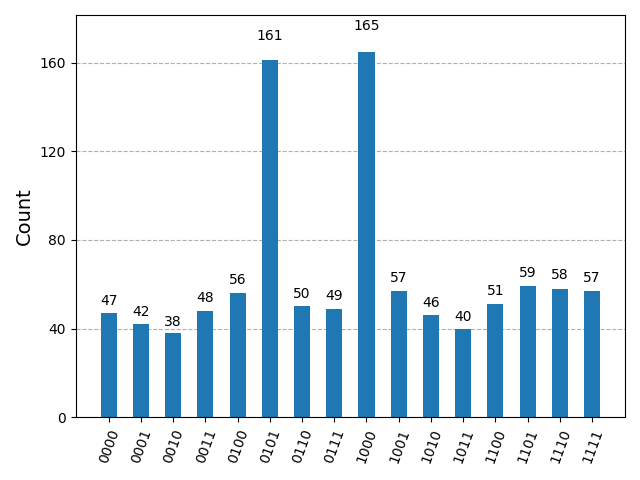

Note that in this particular example we have two correct subsets. However, since we used M=1 when choosing the number of Grover iteration, the output only gave us one subset. If we recalculate the number of Grover iterations by setting M=2 we get the following output.

Set: [2, 3, 5, 7]

Target: 7

Bitstring: 1000

Subset: [np.int64(7)]

Result: Solution found!

Bitstring: 0101

Subset: [np.int64(2), np.int64(5)]

Result: Solution found!

{'0010': 2, '1100': 2, '0100': 5, '0110': 4, '1011': 3, '0000': 3, '1001': 4, '1010': 5, '0001': 1, '0011': 5, '1101': 2, '1111': 5, '0111': 1, '1110': 2, '1000': 471, '0101': 509}


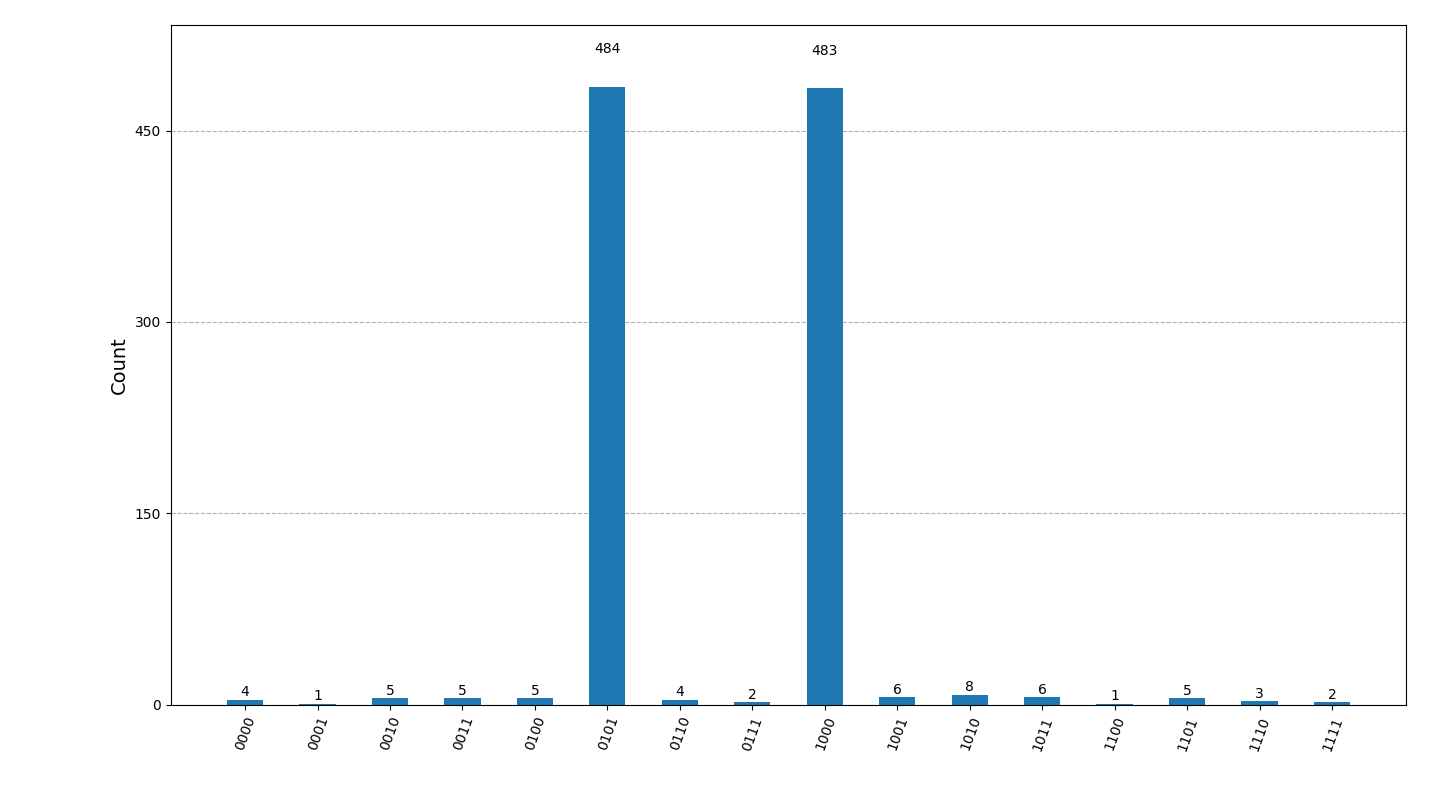

## 10. BENCHMARK EXAMPLES

In [ ]:
benchmark_examples = [
    ([2, 3, 5, 7], 7),
    ([1, 2, 4, 7], 6),
    ([1, 3, 4, 6], 10),
    ([1, 2, 3, 4], 5),
    ([2, 4, 6, 7], 3),
]

for set, target in benchmark_examples:
    print("\n==============================")
    print("Set:", set)
    print("Target:", target)

    n = len(set)

    oracle_circuit = oracle(set, target)
    oracle_gate = oracle_circuit.to_gate(label="Oracle")

    grover_circuit = QuantumCircuit(*oracle_circuit.qregs)

    grover_circuit.h(list(range(n)))

    iterations = floor((math.pi / 4) * math.sqrt(2 ** n))

    for _ in range(iterations):
        grover_circuit.append(oracle_gate, grover_circuit.qubits)
        add_diffuser(grover_circuit, n)

    creg = ClassicalRegister(n, "meas")
    grover_circuit.add_register(creg)
    grover_circuit.measure(list(range(n)), creg)

    sim = AerSimulator()
    compiled = transpile(grover_circuit, sim)
    result = sim.run(compiled, shots=1024).result()
    counts = result.get_counts()

    best_bitstring = max(counts, key=counts.get)
    answer = bitstring_to_subset(best_bitstring, set)

    print("Best bitstring:", best_bitstring)
    print("Subset:", answer)


    if sum(answer) == target:
        print("Result: Solution found!")
    else:
        print("Result: No solution found with high probability.")




Set: [2, 3, 5, 7]
Target: 7
Best bitstring: 0101
Subset: [np.int64(2), np.int64(5)]
Result: Solution found!

Set: [1, 2, 4, 7]
Target: 6
Best bitstring: 0110
Subset: [np.int64(2), np.int64(4)]
Result: Solution found!

Set: [1, 3, 4, 6]
Target: 10
Best bitstring: 1100
Subset: [np.int64(4), np.int64(6)]
Result: Solution found!

Set: [1, 2, 3, 4]
Target: 5
Best bitstring: 0110
Subset: [np.int64(2), np.int64(3)]
Result: Solution found!

Set: [2, 4, 6, 7]
Target: 3
Best bitstring: 1110
Subset: [np.int64(4), np.int64(6), np.int64(7)]
Result: No solution found with high probability.
